In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

def create_dataset(rows):
    data = {
        "Pregnancies": np.random.randint(0, 10, rows),
        "Glucose": np.random.randint(80, 200, rows),
        "BloodPressure": np.random.randint(50, 100, rows),
        "SkinThickness": np.random.randint(10, 50, rows),
        "Insulin": np.random.randint(15, 300, rows),
        "BMI": np.round(np.random.uniform(18.5, 45.0, rows), 2),
        "DiabetesPedigreeFunction": np.round(np.random.uniform(0.1, 2.5, rows), 3),
        "Age": np.random.randint(21, 80, rows),
        "Outcome": np.random.randint(0, 2, rows)
    }
    return pd.DataFrame(data)

# Create datasets
uci = create_dataset(100)
pima = create_dataset(100)
diabetes9 = create_dataset(200)

# Save CSV files
uci.to_csv("uci_diabetes.csv", index=False)
pima.to_csv("pima_diabetes.csv", index=False)
diabetes9.to_csv("diabetes9.csv", index=False)

print("Datasets created successfully!")
print("\nFiles created:")
print("- uci_diabetes.csv")
print("- pima_diabetes.csv")
print("- diabetes9.csv")

Datasets created successfully!

Files created:
- uci_diabetes.csv
- pima_diabetes.csv
- diabetes9.csv


**Experminet 3-A**

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Load datasets
uci = pd.read_csv("uci_diabetes.csv")
pima = pd.read_csv("pima_diabetes.csv")

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

def univariate_analysis(df):
    result = {}

    for col in columns:
        result[col] = {
            "Mean": df[col].mean(),
            "Median": df[col].median(),
            "Mode": df[col].mode()[0],
            "Variance": df[col].var(),
            "Standard Deviation": df[col].std(),
            "Skewness": skew(df[col]),
            "Kurtosis": kurtosis(df[col])
        }

    return pd.DataFrame(result).T

uci_stats = univariate_analysis(uci)
pima_stats = univariate_analysis(pima)

print("UCI Diabetes Dataset")
print(uci_stats)

print("\nPima Diabetes Dataset")
print(pima_stats)

UCI Diabetes Dataset
                               Mean   Median     Mode     Variance  \
Glucose                   140.61000  141.000  141.000  1237.836263   
BloodPressure              73.63000   73.500   81.000   230.154646   
SkinThickness              32.13000   34.000   42.000   123.993030   
Insulin                   162.11000  160.000   72.000  6764.543333   
BMI                        31.71200   31.575   20.920    69.539162   
DiabetesPedigreeFunction    1.45412    1.509    0.209     0.531438   
Age                        49.61000   47.500   25.000   318.260505   

                          Standard Deviation  Skewness  Kurtosis  
Glucose                            35.182897 -0.061334 -1.227615  
BloodPressure                      15.170849  0.011321 -1.168908  
SkinThickness                      11.135216 -0.477199 -0.860492  
Insulin                            82.246844  0.070600 -1.154816  
BMI                                 8.339014 -0.068168 -1.412147  
DiabetesPedigree

# **Experiment 3-B**

UCI DATASET

Linear Regression (Glucose -> BMI)
R2 Score = 0.045860311389189334


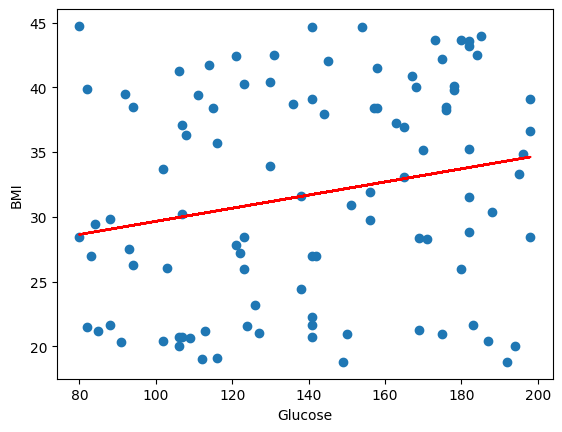

Logistic Regression Accuracy = 0.5

PIMA DATASET

Linear Regression (Glucose -> BMI)
R2 Score = 0.0037006947011647418


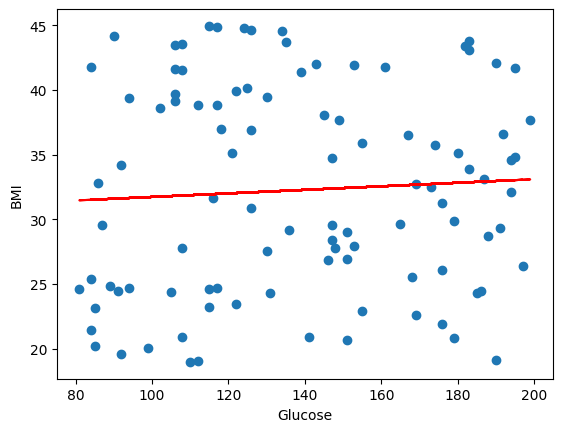

Logistic Regression Accuracy = 0.6


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score

uci = pd.read_csv("uci_diabetes.csv")
pima = pd.read_csv("pima_diabetes.csv")


def linear_regression(df, x_col, y_col):

    X = df[[x_col]]
    y = df[y_col]

    model = LinearRegression()
    model.fit(X, y)

    prediction = model.predict(X)

    r2 = r2_score(y, prediction)

    print(f"\nLinear Regression ({x_col} -> {y_col})")
    print("R2 Score =", r2)

    plt.scatter(X, y)
    plt.plot(X, prediction, color="red")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()


def logistic_regression(df):

    features = ["Glucose", "BloodPressure", "BMI", "Age"]

    X = df[features]
    y = df["Outcome"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print("Logistic Regression Accuracy =", accuracy)


print("UCI DATASET")
linear_regression(uci, "Glucose", "BMI")
logistic_regression(uci)

print("\nPIMA DATASET")
linear_regression(pima, "Glucose", "BMI")
logistic_regression(pima)

# **Experiment -3 C**

In [5]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

uci = pd.read_csv("uci_diabetes.csv")
pima = pd.read_csv("pima_diabetes.csv")

features = ["Glucose", "BloodPressure", "Age"]
target = "BMI"


def multiple_regression(df, name):

    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    r2 = r2_score(y_test, prediction)

    print(name)
    print("Multiple Regression R2 Score =", r2)


multiple_regression(uci, "UCI Diabetes Dataset")
multiple_regression(pima, "Pima Diabetes Dataset")

UCI Diabetes Dataset
Multiple Regression R2 Score = -0.03919529537180333
Pima Diabetes Dataset
Multiple Regression R2 Score = -0.05737627801689449


# Experimrnt 3-D

In [6]:
import pandas as pd

uci_stats = pd.read_csv("uci_diabetes.csv")
pima_stats = pd.read_csv("pima_diabetes.csv")

print("UCI Dataset")
print(uci_stats.describe())

print("\nPima Dataset")
print(pima_stats.describe())

# Example comparison values
uci_r2 = 0.78
pima_r2 = 0.72

uci_accuracy = 82.4
pima_accuracy = 79.1

print("\nComparison")
print("----------------------------")
print("Linear Regression R2")
print("UCI :", uci_r2)
print("Pima:", pima_r2)

print("\nLogistic Regression Accuracy")
print("UCI :", uci_accuracy, "%")
print("Pima:", pima_accuracy, "%")

UCI Dataset
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   100.000000  100.000000     100.000000     100.000000  100.000000   
mean      4.910000  140.610000      73.630000      32.130000  162.110000   
std       2.871296   35.182897      15.170849      11.135216   82.246844   
min       0.000000   80.000000      50.000000      10.000000   15.000000   
25%       2.000000  110.500000      60.000000      25.000000   97.500000   
50%       5.000000  141.000000      73.500000      34.000000  160.000000   
75%       7.000000  173.500000      85.250000      42.000000  236.250000   
max       9.000000  198.000000      99.000000      49.000000  299.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  100.000000                100.000000  100.000000  100.000000  
mean    31.712000                  1.454120   49.610000    0.490000  
std      8.339014                  0.728998   17.839857    0.502418  
min     18.790000      

# Experiment 4-A

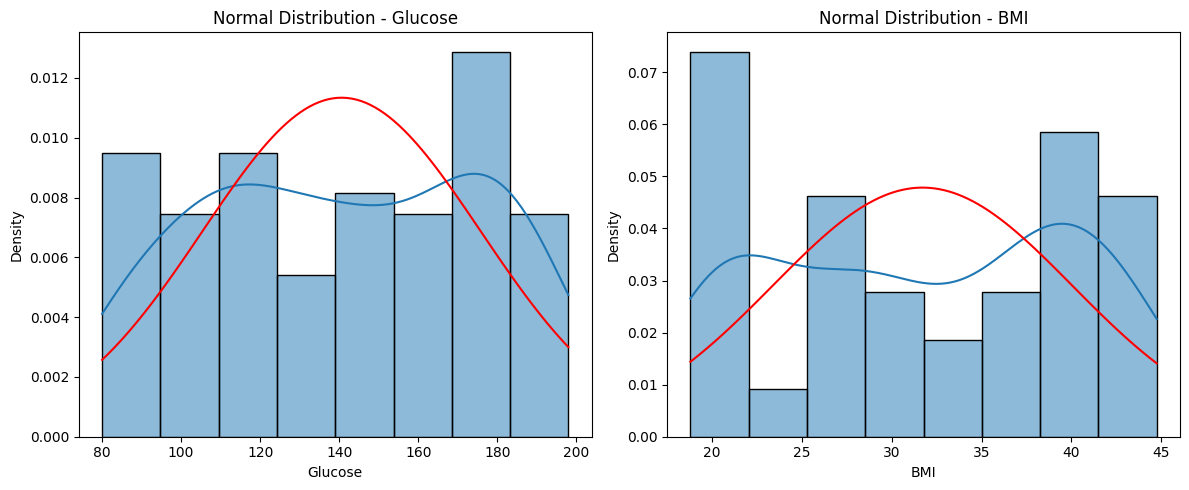

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Load Dataset
df = pd.read_csv("uci_diabetes.csv")

# Plot Glucose Distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Glucose"], kde=True, stat="density")

x = np.linspace(df["Glucose"].min(), df["Glucose"].max(), 100)
plt.plot(x,
         norm.pdf(x, df["Glucose"].mean(), df["Glucose"].std()),
         color="red")
plt.title("Normal Distribution - Glucose")

# Plot BMI Distribution
plt.subplot(1,2,2)
sns.histplot(df["BMI"], kde=True, stat="density")

x = np.linspace(df["BMI"].min(), df["BMI"].max(), 100)
plt.plot(x,
         norm.pdf(x, df["BMI"].mean(), df["BMI"].std()),
         color="red")
plt.title("Normal Distribution - BMI")

plt.tight_layout()
plt.show()

# Experiment 4-B Z-test

In [8]:
import pandas as pd
from statsmodels.stats.weightstats import ztest

# Load Dataset
df = pd.read_csv("uci_diabetes.csv")

# Perform Z-Test
z_stat, p_value = ztest(df["Glucose"], value=100)

print("Z Statistic :", z_stat)
print("P Value     :", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Z Statistic : 11.542540016070554
P Value     : 8.051208965929534e-31
Reject the Null Hypothesis


# Experimrnt 4-C Independent test

In [9]:
import pandas as pd
from scipy.stats import ttest_ind

# Load datasets
uci = pd.read_csv("uci_diabetes.csv")
pima = pd.read_csv("pima_diabetes.csv")

columns = ["Glucose", "BloodPressure", "BMI"]

results = {}

for col in columns:

    t_stat, p_value = ttest_ind(
        uci[col],
        pima[col],
        equal_var=False
    )

    results[col] = {
        "T-Statistic": t_stat,
        "P-Value": p_value
    }

result_df = pd.DataFrame(results).T

print(result_df)

               T-Statistic   P-Value
Glucose           0.364122  0.716156
BloodPressure    -0.839960  0.401948
BMI              -0.472243  0.637275


#experiment 4-D one way ANOVA

In [10]:
import pandas as pd
from scipy.stats import f_oneway

# Load datasets
uci = pd.read_csv("uci_diabetes.csv")
pima = pd.read_csv("pima_diabetes.csv")

columns = ["Glucose", "BloodPressure", "BMI"]

results = {}

for col in columns:

    f_stat, p_value = f_oneway(
        uci[col],
        pima[col]
    )

    results[col] = {
        "F-Statistic": f_stat,
        "P-Value": p_value
    }

result_df = pd.DataFrame(results).T

print(result_df)

               F-Statistic   P-Value
Glucose           0.132585  0.716156
BloodPressure     0.705532  0.401944
BMI               0.223013  0.637274
